Train Accuracy : 0.815
Validation Accuracy  : 0.82
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       156
           1       0.62      0.45      0.53        44

    accuracy                           0.82       200
   macro avg       0.74      0.69      0.71       200
weighted avg       0.81      0.82      0.81       200



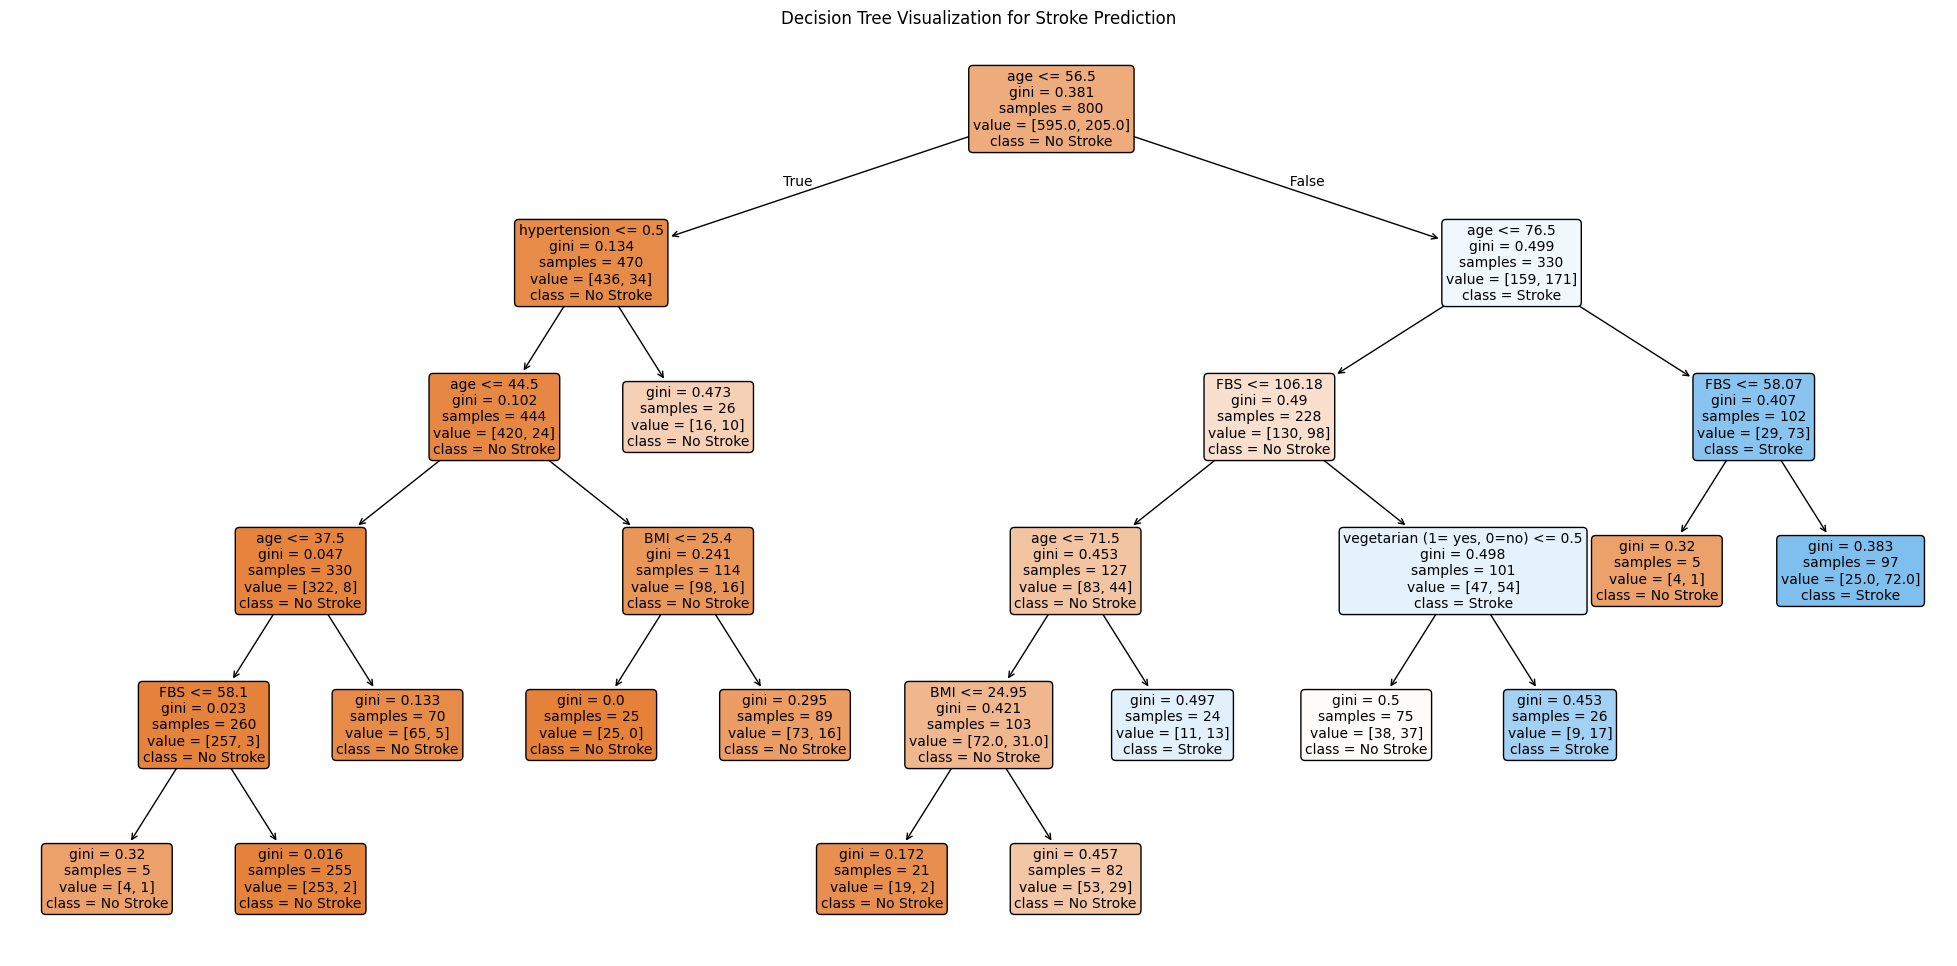

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

data_path = 'data/updated_cleaned_patient_data.csv'
data = pd.read_csv(data_path)

data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop('stroke', axis=1)
y = data_encoded['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=100, 
    min_samples_leaf=5,
    random_state=42,
)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train Accuracy :", accuracy_score(y_train, train_pred))
print("Validation Accuracy  :", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))

#Graph
# 1. ตั้งค่าขนาดของภาพ (ปรับตัวเลขได้ถ้าภาพเล็กไป)
plt.figure(figsize=(25, 12))

# 2. วาดกราฟ
plot_tree(
    model,
    feature_names=X.columns,      # ใส่ชื่อคอลัมน์เพื่อให้รูว่าโหนดนั้นเช็คค่าอะไร
    class_names=['No Stroke', 'Stroke'], # ใส่ชื่อผลลัพธ์ (0=No Stroke, 1=Stroke)
    filled=True,                  # ระบายสีตามความมั่นใจ (สีเข้ม=มั่นใจมาก)
    rounded=True,                 # ทำให้กล่องมน ดูง่ายขึ้น
    fontsize=10                   # ขนาดตัวอักษร
)

# 3. แสดงผล
plt.title("Decision Tree Visualization for Stroke Prediction")
plt.show()